(streaming_dataset)=

# Out-of-core minibatch variational inference with StreamingDataset

:::{post} June 2026
:tags: variational inference, minibatch, out-of-core, ADVI
:category: intermediate, how-to
:author: Yicheng (Ethan) Yang
:::

`pm.Minibatch` random-indexes an array that must be fully resident in RAM, so
minibatch variational inference is capped at datasets that fit in memory -- the
very regime where minibatching is meant to help. `StreamingDataset` feeds
minibatches from an arbitrary source (a generator, a directory of Parquet shards,
...) into a small `pytensor.shared` buffer, so peak memory is bounded by the
buffer and is independent of the dataset size `N`.

The unbiased-gradient rescaling is unchanged from `pm.Minibatch`: pass
`total_size=N` to the observed distribution and PyMC scales the minibatch
log-likelihood by `N / batch_size`. The one extra obligation is shuffling -- a
streaming source is only as well mixed as the order it yields rows in -- which we
handle with `shuffle_buffer`.

We use a modest `N` here so the notebook runs in seconds and the two posteriors
are easy to compare; the streaming machinery is identical at any size, and the
final section shows why it matters at scale.

In [1]:
import glob
import tempfile

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import pymc as pm

from pymc.variational.streaming import StreamingDataset, shuffle_buffer

RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")

## Put a dataset on disk and forget the array

We synthesise a logistic-regression dataset, write it to Parquet shards, and
delete the in-memory copy. From here on the data only exists on disk -- exactly
the situation `StreamingDataset` is for.

In [2]:
N = 30_000
b_true = np.array([0.4, -1.2, 0.8, -0.5])  # intercept + 3 slopes

X = rng.normal(size=(N, 3))
p = 1 / (1 + np.exp(-(b_true[0] + X @ b_true[1:])))
y = (rng.random(N) < p).astype("float64")
table = np.column_stack([X, y]).astype("float64")  # 3 features + 1 observed column

shard_dir = tempfile.mkdtemp(prefix="streaming_demo_")
for i, s in enumerate(range(0, N, 5_000)):
    block = table[s : s + 5_000]
    pq.write_table(
        pa.table({f"c{j}": block[:, j] for j in range(4)}),
        f"{shard_dir}/part_{i:03d}.parquet",
    )
del table  # the data now lives only on disk
print(len(glob.glob(f"{shard_dir}/*.parquet")), "shards written")

6 shards written


## Stream minibatches off disk and fit with ADVI

`chunks()` lazily reads one shard at a time; `shuffle_buffer` accumulates rows
into a buffer, shuffles them, and yields fixed-size batches (carrying over any
remainder so no row is lost). `StreamingDataset` owns the `pytensor.shared`
buffer the model observes; `total_size=ds.total_size` triggers the `N / batch_size`
rescaling and a `fit_callback()` advances the buffer each step.

In [3]:
def chunks():
    for path in sorted(glob.glob(f"{shard_dir}/*.parquet")):
        t = pq.read_table(path)
        yield np.column_stack([t.column(c).to_numpy() for c in t.column_names])


batch_size = 1024
ds = StreamingDataset(
    shuffle_buffer(chunks, buffer_size=15_000, batch_size=batch_size, seed=0),
    batch_size=batch_size,
    sample_shape=(4,),  # 3 features + 1 observed column, streamed together
    total_size=N,
)
ds.advance()  # seed the buffer

with pm.Model():
    b = pm.Normal("b", 0.0, 3.0, shape=4)
    buf = ds.as_tensor()
    logit = b[0] + b[1] * buf[:, 0] + b[2] * buf[:, 1] + b[3] * buf[:, 2]
    pm.Bernoulli("y", logit_p=logit, observed=buf[:, 3], total_size=ds.total_size)
    approx = pm.fit(
        30_000,
        method="advi",
        obj_optimizer=pm.adam(learning_rate=0.008),
        callbacks=[ds.fit_callback()],
        progressbar=False,
    )
    idata_stream = approx.sample(1000)

Finished [100%]: Average Loss = 531.45


The negative-ELBO trace shows the fit converging while only ever holding a
`batch_size` buffer in memory:

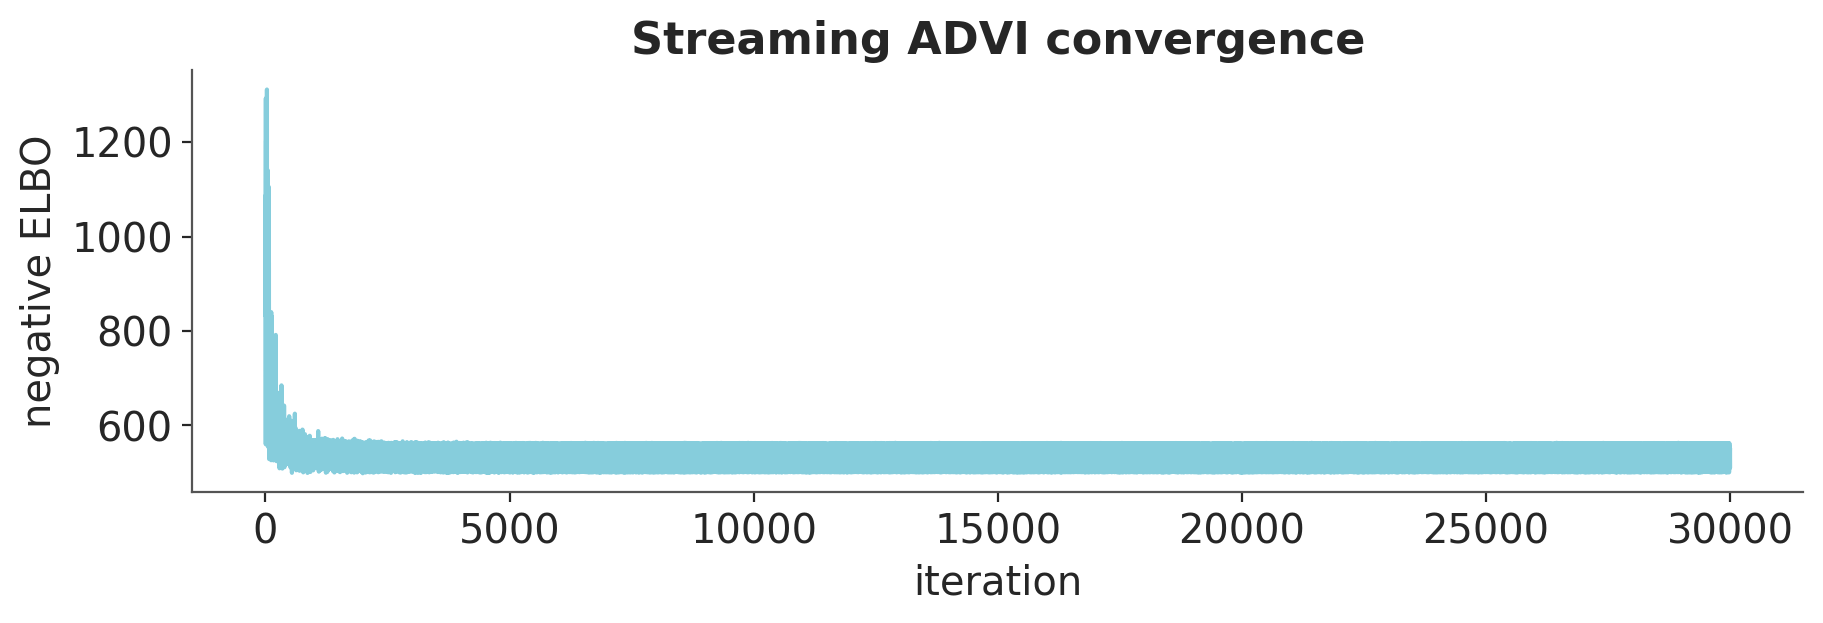

In [4]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(approx.hist, alpha=0.6)
ax.set(xlabel="iteration", ylabel="negative ELBO", title="Streaming ADVI convergence");

## The same posterior as in-RAM `pm.Minibatch`

For comparison, the status-quo fit that keeps the whole dataset in memory.
Streaming changes *where the data lives*, not the inference: the two posteriors
land on top of each other (both show ADVI's characteristic mild bias relative to
the dashed ground truth, but they agree with each other).

In [5]:
with pm.Model():
    b = pm.Normal("b", 0.0, 3.0, shape=4)
    xb, zb, sb, yb = pm.Minibatch(
        X[:, 0].copy(), X[:, 1].copy(), X[:, 2].copy(), y, batch_size=batch_size
    )
    pm.Bernoulli(
        "y", logit_p=b[0] + b[1] * xb + b[2] * zb + b[3] * sb, observed=yb, total_size=N
    )
    approx_inram = pm.fit(
        30_000, method="advi", obj_optimizer=pm.adam(learning_rate=0.008), progressbar=False
    )
    idata_inram = approx_inram.sample(1000)

Finished [100%]: Average Loss = 531.03


/tmp/claude-501/ipykernel_20806/503280259.py:13: UserWarning: The figure layout has changed to tight
  fig.tight_layout();


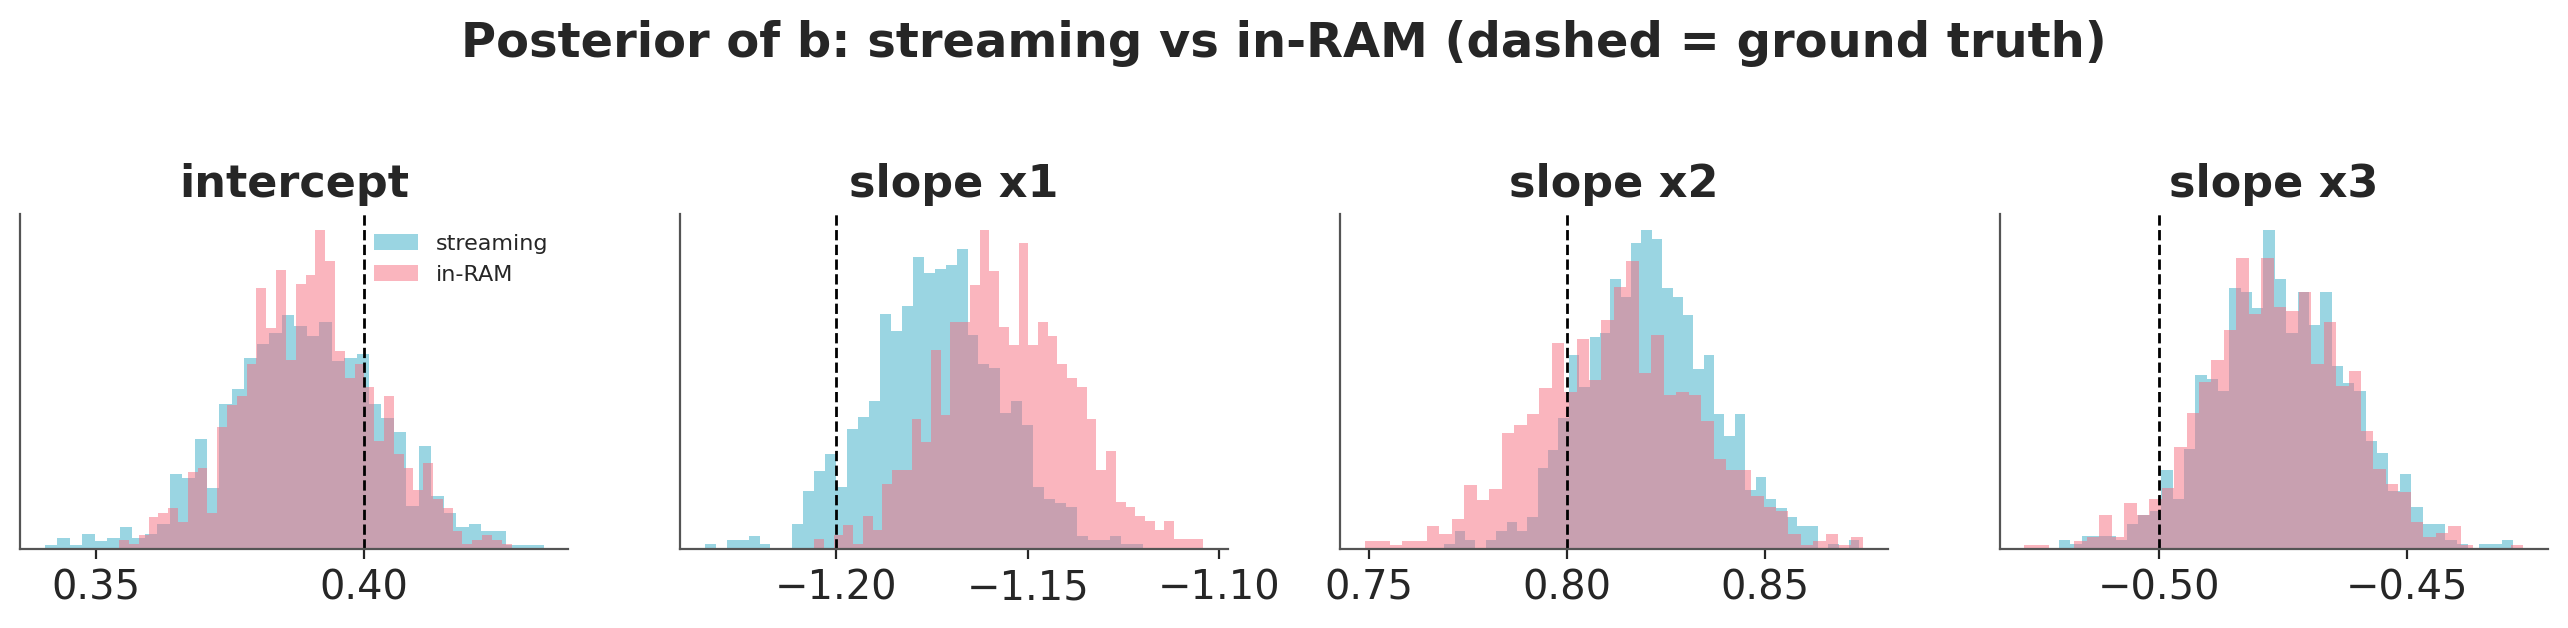

In [6]:
bs_stream = idata_stream.posterior["b"].values.reshape(-1, 4)
bs_inram = idata_inram.posterior["b"].values.reshape(-1, 4)
names = ["intercept", "slope x1", "slope x2", "slope x3"]

fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for k, ax in enumerate(axes):
    ax.hist(bs_stream[:, k], bins=40, density=True, alpha=0.5, label="streaming")
    ax.hist(bs_inram[:, k], bins=40, density=True, alpha=0.5, label="in-RAM")
    ax.axvline(b_true[k], color="k", ls="--", lw=1)
    ax.set(title=names[k], yticks=[])
axes[0].legend(fontsize=8)
fig.suptitle("Posterior of b: streaming vs in-RAM (dashed = ground truth)", y=1.04)
fig.tight_layout();

## Why bother: memory

Both paths feed the same `batch_size` to ADVI, but `pm.Minibatch` keeps all `N`
rows resident, so the array it must hold grows linearly in `N`; `StreamingDataset`
only ever holds one `batch_size` buffer. The dense `float64` design matrix is the
dominant cost, so its footprint is a faithful proxy for the gap:

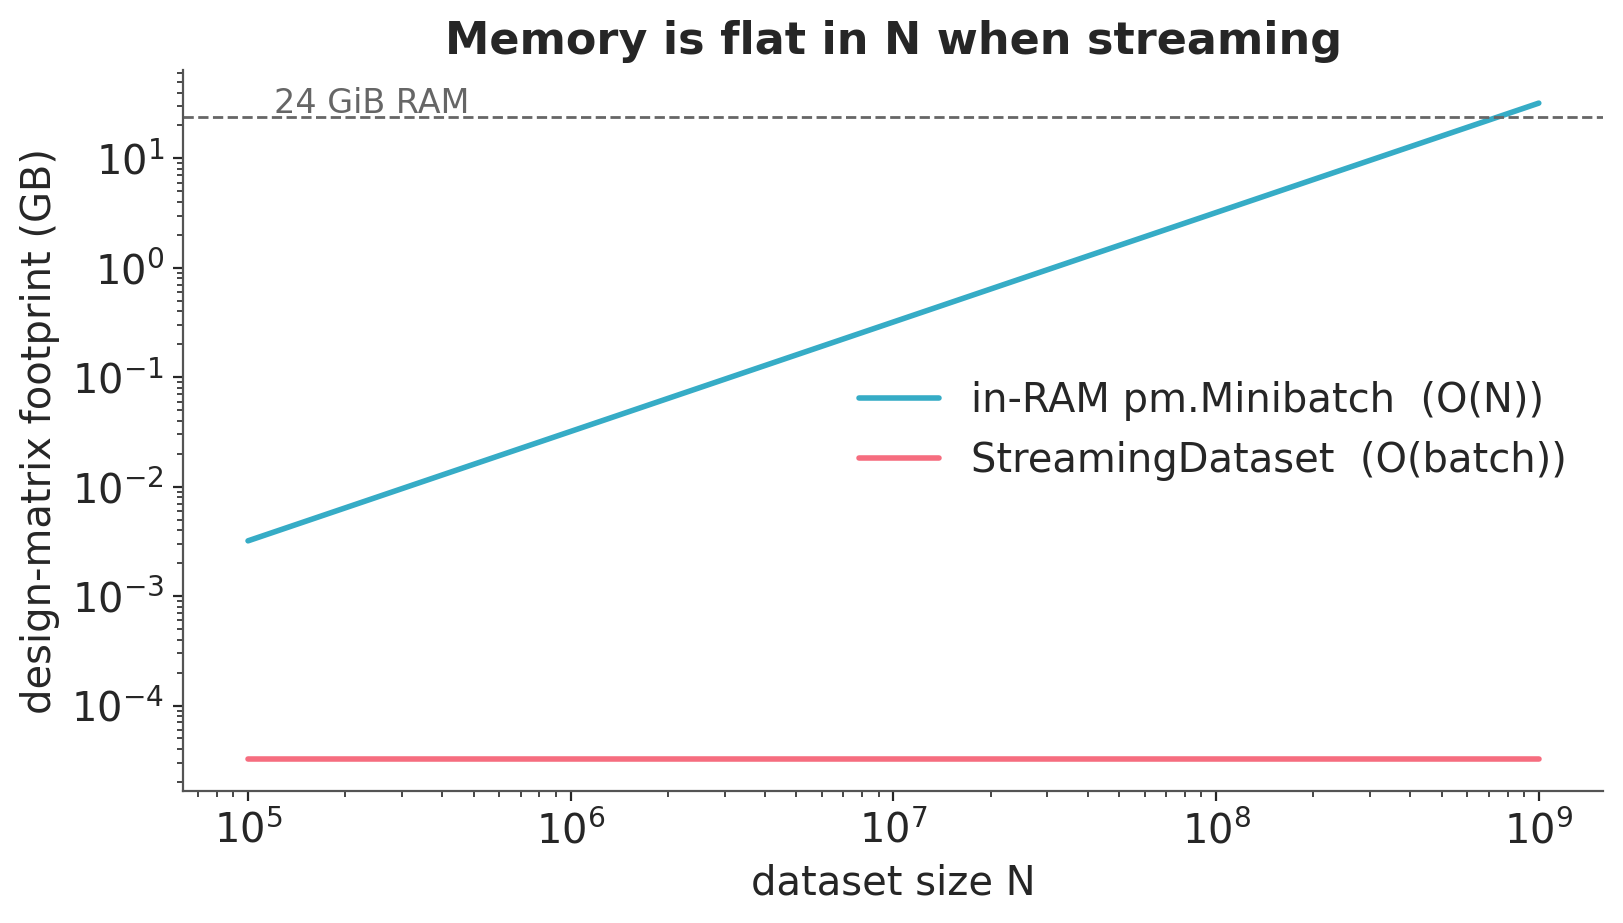

In [7]:
ncols = 4  # 3 features + observed
n_grid = np.logspace(5, 9, 50)            # 1e5 .. 1e9 rows
inram_gb = n_grid * ncols * 8 / 1e9       # whole dataset resident
stream_gb = np.full_like(n_grid, batch_size * ncols * 8 / 1e9)  # just the buffer

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.loglog(n_grid, inram_gb, label="in-RAM pm.Minibatch  (O(N))", lw=2)
ax.loglog(n_grid, stream_gb, label="StreamingDataset  (O(batch))", lw=2)
ax.axhline(24, color="0.4", ls="--", lw=1)
ax.text(1.2e5, 26, "24 GiB RAM", color="0.4")
ax.set(xlabel="dataset size N", ylabel="design-matrix footprint (GB)",
       title="Memory is flat in N when streaming")
ax.legend();

On a real 122 GB order-book dataset (121.8 M rows) this is not just the array
size: measured in-RAM peak memory grew to ~9.1 GB at 122 M rows (extrapolating to
out-of-memory near ~372 M on a 24 GiB machine), while the streaming run stayed
flat at ~0.55 GB -- at posteriors agreeing to within ADVI noise.

## When to reach for it

* Use `pm.Minibatch` when the data fits in RAM: it is simpler and its random
  index gives perfectly i.i.d. minibatches for free.
* Use `StreamingDataset` when it does not: it keeps memory flat in `N` by
  streaming from disk. The cost is a `fit_callback` to advance the buffer and the
  responsibility to shuffle (pre-shuffle on disk, or interleave shards, then use
  `shuffle_buffer`); a bounded buffer over strongly ordered data only
  block-shuffles it and biases the posterior.

## Authors

* Authored by Yicheng (Ethan) Yang in June 2026 for the Google Summer of Code
  project *Streaming Variational Inference for Large Datasets* (PyMC / NumFOCUS).

## References

* Hoffman, M. D., Blei, D. M., Wang, C., & Paisley, J. (2013). Stochastic
  variational inference. *Journal of Machine Learning Research*, 14(1).
* Kucukelbir, A., Tran, D., Ranganath, R., Gelman, A., & Blei, D. M. (2017).
  Automatic differentiation variational inference. *JMLR*, 18(1).

In [8]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor,pyarrow

Last updated: Fri, 05 Jun 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.13.0

pytensor: 3.0.3
pyarrow : 24.0.0

arviz     : 1.1.0
matplotlib: 3.10.9
numpy     : 2.4.6
platform  : 1.0.8
pyarrow   : 24.0.0
pymc      : 6.0.1

Watermark: 2.6.0



:::{include} ../page_footer.md
:::